In [2]:
import os
import json
import pandas as pd
from os.path import join
import matplotlib.pyplot as plt
from pprint import pprint
import seaborn as sns
import numpy as np

In [3]:
def get_dataset_name(dataset_id, nnUNet_raw="data/nnUNet_raw"):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [dataset_name for dataset_name in os.listdir(nnUNet_raw) if dataset_name.startswith(f"Dataset{dataset_id}") and os.path.isdir(join(nnUNet_raw, dataset_name))]
    assert len(dataset_name) == 1, f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1"
    return dataset_name[0]

def extract_params(model_dir):
    metrics_file = f"{model_dir}/model_analysis.json"
    with open(metrics_file, 'r') as f:
        metrics = json.load(f)
    return metrics['parameters']['total']

def get_results(model_dir, split="val", fold=0):
    if split == "val":
        metrics_file = f"{model_dir}/fold_{fold}/validation/summary.json"
    else:
        raise ValueError(f"Not implemented for split {split}")

    with open(metrics_file, 'r') as f:
        metrics = json.load(f)

    results = dict(metrics['foreground_mean'])

    dice_per_case = []
    for case in metrics.get('metric_per_case', []):
        case_metrics = case.get('metrics', {})
        class_key = next(iter(case_metrics), None)
        if class_key is None:
            continue
        dice_val = case_metrics[class_key].get('Dice')
        if dice_val is not None:
            dice_per_case.append(float(dice_val))

    dice_per_case = np.asarray(dice_per_case, dtype=float)
    dice_per_case = dice_per_case[np.isfinite(dice_per_case)]
    results['Dice_std'] = float(np.std(dice_per_case)) if dice_per_case.size > 0 else np.nan
    return results

In [4]:
from PIL import Image, UnidentifiedImageError
from pathlib import Path
def get_baseline_results_from_log(model_dir):
    log_path = f"{model_dir}/fold_0/log.csv"
    df = pd.read_csv(log_path)
    dice = df['val_dice'].iloc[-1]
    return dice

def get_baseline_results_csv(model_dir, dataset_name):
    log_path = f"{model_dir}/fold_0/test/results.csv"
    df = pd.read_csv(log_path)
    dice = df[df['test_dataset_name'] == dataset_name]['dice'].values[0]
    return dice / 100


def get_baseline_results(dataset_id, models=["TinyUNet", "CMUNeXt", "UNeXt"], results_dir="data/nnUNet_results"):
    dataset_name = get_dataset_name(dataset_id)
        
    results = {model: {'dice': None, 'params': None} for model in models}
    for model in models:
        if model == "TinyUNet":
            trainer = "TinyUNetTrainer"
            model_dir = f"/home/ultrai/UltrAi/UNeXt/models/{model}/{dataset_name}"
        elif model == "CMUNeXt":
            trainer = "CMUNeXtTrainer"
            model_dir = f"/home/ultrai/UltrAi/CMUNeXt/models/CMUNeXt-S/{dataset_name}"
        elif model == "UNeXt":
            # dataset_id = 303
            # dataset_name = get_dataset_name(dataset_id)
            trainer = "UNeXtTrainer_100epochs"
            model_dir = f"/home/ultrai/UltrAi/UNeXt/models/UNext/{dataset_name}"
        else:
            raise ValueError(f"Unknown model: {model}. Please choose from {', '.join(models)}")

        params = extract_params(model_dir)
        # dice = get_results(model_dir, split=split, fold=fold)['Dice']
        if model == "CMUNeXt":
            dice = get_baseline_results_csv(model_dir, dataset_name)
        else:
            dice = get_baseline_results_from_log(model_dir)
        results[model]['dice'] = round(dice * 100, 2)
        results[model]['params'] = params
    return results


def get_jacobian_metric(cfg, dataset_name, nas_metrics_dir="results/nas_metrics", encoder_only=False, use_pretrained=False, batches="all"):
    if encoder_only:
        csv_path = join(nas_metrics_dir, f"{dataset_name}_metrics_encoder_only_b{batches}.csv")
    else:
        csv_path = join(nas_metrics_dir, f"{dataset_name}_metrics_b{batches}.csv")
    if use_pretrained:
        csv_path = csv_path.replace("metrics_", "metrics_pretrained_")
    if not os.path.exists(csv_path):
        return np.nan

    df = pd.read_csv(csv_path)
    if df.empty or "cfg" not in df.columns or "jacobian" not in df.columns:
        return np.nan

    df = df[df["cfg"] == cfg]
    if df.empty:
        return np.nan

    value = df["jacobian"].iloc[-1]
    if pd.isna(value):
        return np.nan
    return float(value)


def select_precollapse_config_from_jacobian(params_list, jacobian_list, pre_collapse_rank=1, min_seg=2):
    """Select pre-collapse config using only Jacobian curve shape.

    Fits a 2-segment piecewise linear model on (log10(params), jacobian).
    The breakpoint estimates the collapse boundary (small-model side vs stable side).

    pre_collapse_rank:
        1 -> last config before collapse (closest to boundary on stable side)
        2 -> second-last config before collapse
    """
    x = np.asarray(params_list, dtype=float)
    y = np.asarray([np.nan if pd.isna(v) else float(v) for v in jacobian_list], dtype=float)

    valid = np.isfinite(x) & np.isfinite(y) & (x > 0)  # keep same convention as results.ipynb

    if valid.sum() < (2 * min_seg + 1):
        return None, None

    valid_idx = np.flatnonzero(valid)
    xv = np.log10(x[valid])
    yv = np.clip(y[valid], 1e-12, None)

    n = len(xv)
    if n < (2 * min_seg + 1):
        return None, None

    best_b = None
    best_sse = np.inf

    for b in range(min_seg - 1, n - min_seg):
        x1, y1 = xv[: b + 1], yv[: b + 1]
        x2, y2 = xv[b + 1 :], yv[b + 1 :]

        p1 = np.polyfit(x1, y1, 1)
        p2 = np.polyfit(x2, y2, 1)

        y1_hat = p1[0] * x1 + p1[1]
        y2_hat = p2[0] * x2 + p2[1]
        sse = np.sum((y1 - y1_hat) ** 2) + np.sum((y2 - y2_hat) ** 2)

        if sse < best_sse:
            best_sse = sse
            best_b = b

    if best_b is None:
        return None, None

    # Boundary is between valid positions best_b and best_b+1.
    # Pre-collapse picks are on the stable (larger-model) side: best_b+1, best_b+2, ...
    pick_valid_pos = best_b + int(pre_collapse_rank)
    if pick_valid_pos >= len(valid_idx):
        pick_valid_pos = len(valid_idx) - 1

    pick_idx = int(valid_idx[pick_valid_pos])
    boundary_idx = int(valid_idx[best_b + 1])
    return pick_idx, boundary_idx


# One image per dataset: for each dataset, plot 2 rows x num_cfg columns
# Row 0: raw image
# Row 1: GT + Pred overlay
# Title format: cfg:dice



def _is_nifti(path):
    name = str(path).lower()
    return name.endswith('.nii') or name.endswith('.nii.gz')


def _case_id_from_path(path):
    p = Path(path)
    name = p.name
    if name.lower().endswith('.nii.gz'):
        return name[:-7]
    if name.lower().endswith('.nii'):
        return name[:-4]
    return p.stem


def _center_slice(arr):
    out = np.asarray(arr)
    while out.ndim > 2:
        out = np.take(out, indices=out.shape[-1] // 2, axis=-1)
    return out


def _read_image_array(path):
    path = Path(path)

    if _is_nifti(path):
        # Prefer nibabel; fallback to SimpleITK if nibabel is unavailable.
        try:
            import nibabel as nib
            arr = np.asarray(nib.load(str(path)).get_fdata())
        except Exception:
            try:
                import SimpleITK as sitk
                arr = sitk.GetArrayFromImage(sitk.ReadImage(str(path)))
                # SITK gives (z, y, x); move z to last axis for consistent slicing
                if arr.ndim >= 3:
                    arr = np.moveaxis(arr, 0, -1)
            except Exception as e:
                raise RuntimeError(f'Failed to read volumetric image: {path} ({e})')
        return _center_slice(arr)

    try:
        with Image.open(path) as im:
            return np.array(im)
    except UnidentifiedImageError:
        # If extension is unexpected but file is volumetric, try volumetric readers.
        try:
            import nibabel as nib
            arr = np.asarray(nib.load(str(path)).get_fdata())
            return _center_slice(arr)
        except Exception:
            raise


def _normalize_for_display(arr, percentile_normalize=False):
    arr = np.asarray(arr)

    # RGB/RGBA: no percentile normalization; just scale to [0, 1] for display.
    if arr.ndim == 3 and arr.shape[-1] in (3, 4):
        arr = arr.astype(np.float32)
        if arr.max() > 1.0:
            arr = arr / 255.0
        return np.clip(arr, 0, 1)

    arr = arr.astype(np.float32)
    if arr.ndim == 2:
        if percentile_normalize:
            lo, hi = np.percentile(arr, [1, 99])
            if hi > lo:
                arr = (arr - lo) / (hi - lo)
                return np.clip(arr, 0, 1)

        # Non-CT path: min-max normalize for display only.
        mn, mx = float(np.min(arr)), float(np.max(arr))
        if mx > mn:
            arr = (arr - mn) / (mx - mn)
        return np.clip(arr, 0, 1)

    # Fallback
    if arr.max() > 1.0:
        arr = arr / max(arr.max(), 1.0)
    return np.clip(arr, 0, 1)




def _is_ct_dataset_name(dataset_name):
    name = str(dataset_name).lower()
    # Conservative keyword match for CT datasets in this project.
    ct_keywords = ('ct', 'synapse', 'acdc')
    return any(k in name for k in ct_keywords)

def _resolve_raw_case_image(dataset_name, case_id, nnunet_raw='data/nnUNet_raw'):
    ds_root = Path(nnunet_raw) / dataset_name
    search_dirs = [ds_root / 'imagesTr', ds_root / 'imagesTs']

    exts = ['.png', '.nii.gz', '.nii']

    # direct single-file match
    for d in search_dirs:
        for ext in exts:
            p = d / f'{case_id}{ext}'
            if p.exists():
                return _read_image_array(p), [str(p)]

    # channelized match: case_0000.ext, case_0001.ext, ...
    channel_candidates = []
    for d in search_dirs:
        for ext in exts:
            channel_candidates.extend(sorted(d.glob(f'{case_id}_*{ext}')))

    if channel_candidates:
        parsed = []
        for f in channel_candidates:
            name = f.name
            base = name
            if base.lower().endswith('.nii.gz'):
                base = base[:-7]
            elif base.lower().endswith('.nii'):
                base = base[:-4]
            else:
                base = Path(base).stem

            suffix = base.replace(f'{case_id}_', '')
            if suffix.isdigit():
                parsed.append((int(suffix), f))
        parsed.sort(key=lambda x: x[0])
        files = [f for _, f in parsed]

        chans = [_read_image_array(f) for f in files]
        chans = [c if c.ndim == 2 else _center_slice(c) for c in chans]

        if len(chans) >= 3:
            arr = np.stack(chans[:3], axis=-1)
        else:
            arr = chans[0]
        return arr, [str(f) for f in files]

    return None, []


def _load_qualitative_cases(dataset_id, cfg='2d', split='val', fold=0):
    dataset_name = get_dataset_name(dataset_id)
    model_dir = Path(results_dir) / model / dataset_name / f'{trainer}__{plans}__{cfg}'

    if split != 'val':
        raise ValueError('Only split="val" is implemented for qualitative view')

    summary_path = model_dir / f'fold_{fold}' / 'validation' / 'summary.json'
    with open(summary_path, 'r') as f:
        summary = json.load(f)

    rows = []
    for item in summary.get('metric_per_case', []):
        metrics = item.get('metrics', {})
        class_key = next(iter(metrics), None)
        dice = np.nan
        if class_key is not None:
            d = metrics[class_key].get('Dice')
            if d is not None:
                try:
                    dice = float(d)
                except Exception:
                    dice = np.nan

        pred_path = Path(item['prediction_file'])
        gt_path = Path(item['reference_file'])
        case_id = _case_id_from_path(gt_path)

        rows.append({
            'dataset_name': dataset_name,
            'case_id': case_id,
            'dice': dice,
            'pred_path': pred_path,
            'gt_path': gt_path,
        })
    return rows


def _case_rows_for_cfg(dataset_id, cfg):
    try:
        return _load_qualitative_cases(dataset_id, cfg=cfg, split=split, fold=fold)
    except FileNotFoundError:
        return []

def _pick_one_case_id(rows, mode='random', rank=0, seed=0, use_seed=True):
    if len(rows) == 0:
        return None

    finite_rows = [r for r in rows if np.isfinite(r['dice'])]
    nan_rows = [r for r in rows if not np.isfinite(r['dice'])]

    if mode == 'worst':
        ordered = sorted(finite_rows, key=lambda x: x['dice']) + nan_rows
        rank = int(np.clip(rank, 0, len(ordered) - 1))
        return ordered[rank]['case_id']
    if mode == 'best':
        ordered = sorted(finite_rows, key=lambda x: x['dice'], reverse=True) + nan_rows
        rank = int(np.clip(rank, 0, len(ordered) - 1))
        return ordered[rank]['case_id']
    if mode == 'random':
        rng = np.random.default_rng(seed if use_seed else None)
        return rows[int(rng.integers(0, len(rows)))]['case_id']

    raise ValueError("single_case_mode must be one of: 'worst', 'best', 'random'")



In [5]:
trainer = "nnUNetTrainer_100epochs"
plans = "nnUNetPlans"
results_dir = "data/nnUNet_results"
model = "nnunet"
fold = 0
split = "val"

saved to results/dice_vs_params_with_std_with_2d_minus_1std_with_jacobian_pick.png


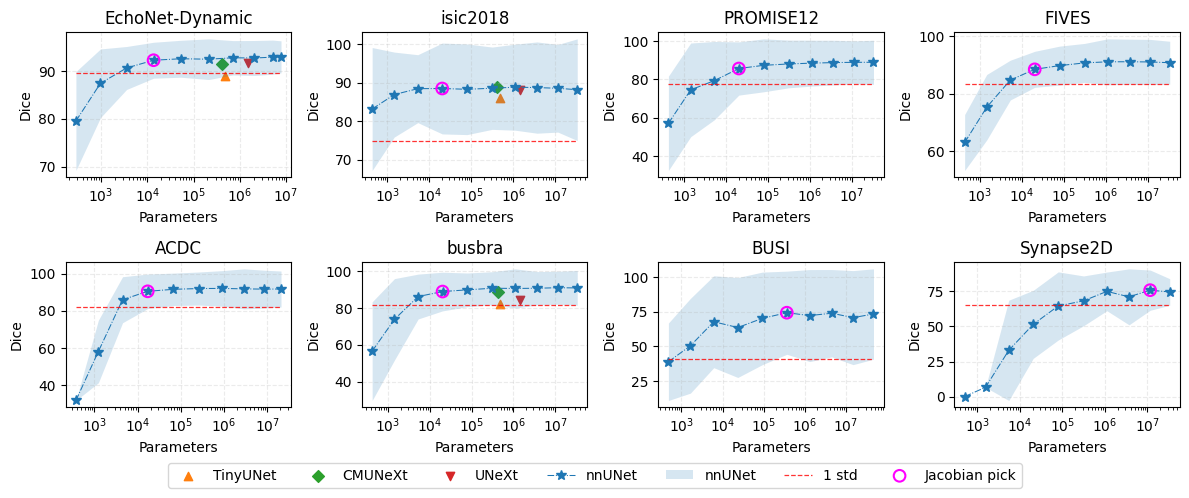

In [6]:
cfgs = [
    "2d_tiny1",
    "2d_tiny2",
    "2d_tiny4",
    "2d_tiny8",
    "2d_tiny16",
    "2d_tiny32",
    "2d_tiny64",
    "2d_tiny128",
    "2d_tiny256",
    "2d",
]

baselines = [
    "TinyUNet",
    "CMUNeXt",
    "UNeXt"
]

dataset_ids = [
    302,
    300,
    308,
    309,
    306,
    301,
    304,
    305,
    # 137,
    # 312,
    # 310,
    # 307,
]

save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

batches = "all"
plot_std = True
plot_2d_minus_1std_line = True
plot_jacobian_pick = True
jacobian_precollapse_rank = 1
min_seg = 2
use_relative_change = True
use_derivative = False
nas_metrics_dir = "results/nas_metrics"
encoder_only = False
use_pretrained = False

jacobian_pick_by_dataset = {}
fig = plt.figure(figsize=(12, 5))
for i, dataset_id in enumerate(dataset_ids):
    dataset_name = get_dataset_name(dataset_id)
    params_list = []
    dice_list = []
    dice_std_list = []
    jacobian_list = []

    for cfg in cfgs:
        model_dir = f"{results_dir}/{model}/{dataset_name}/{trainer}__{plans}__{cfg}"
        params = extract_params(model_dir)
        dice = np.nan
        dice_std = np.nan
        try:
            results = get_results(model_dir, split=split, fold=fold)
            dice = results['Dice'] * 100
            dice_std = results['Dice_std'] * 100
        except FileNotFoundError:
            pass

        jacobian = get_jacobian_metric(
            cfg,
            dataset_name,
            nas_metrics_dir=nas_metrics_dir,
            encoder_only=encoder_only,
            use_pretrained=use_pretrained,
            batches=batches,
        )

        params_list.append(params)
        dice_list.append(dice)
        dice_std_list.append(dice_std)
        jacobian_list.append(jacobian)

    plt.subplot((len(dataset_ids) + 2)//4, 4, i + 1)
    ax = plt.gca()

    colors = sns.color_palette(n_colors=len(baselines) + 1)
    markers = ['^', 'D', 'v', 'X', '^', '<', '>', 'p', 'h', 'H', '8', '1']
    if dataset_id in [300, 301, 302]:
        baseline_results = get_baseline_results(dataset_id, models=baselines, results_dir=results_dir)

        for b, baseline_model in enumerate(baselines):
            dice = baseline_results[baseline_model]['dice']
            params = baseline_results[baseline_model]['params']
            label = baseline_model if i == 0 else "_nolegend_"
            ax.scatter(params, dice, label=label, color=colors[b + 1], marker=markers[b])

    params_arr = np.asarray(params_list, dtype=float)
    valid_params = np.isfinite(params_arr) & (params_arr > 0)
    dice_arr = np.asarray(dice_list, dtype=float)
    dice_std_arr = np.asarray(dice_std_list, dtype=float)

    label = "nnUNet" if i == 0 else "_nolegend_"
    valid_dice = np.isfinite(params_arr) & (params_arr > 0) & np.isfinite(dice_arr)
    if np.any(valid_dice):
        ax.plot(
            params_arr[valid_dice],
            dice_arr[valid_dice],
            marker='*',
            linestyle='dashdot',
            linewidth=0.75,
            markersize=7,
            color=colors[0],
            label=label,
        )

    if plot_std:
        valid_std = valid_dice & np.isfinite(dice_std_arr)
        if np.any(valid_std):
            std_label = "nnUNet" if i == 0 else "_nolegend_"
            x_std = params_arr[valid_std]
            y_std = dice_arr[valid_std]
            s_std = dice_std_arr[valid_std]
            ax.fill_between(
                x_std,
                y_std - s_std,
                y_std + s_std,
                color=colors[0],
                alpha=0.18,
                linewidth=0,
                label=std_label,
            )

    if plot_2d_minus_1std_line and "2d" in cfgs:
        idx_2d = cfgs.index("2d")
        if idx_2d < len(dice_arr) and idx_2d < len(dice_std_arr):
            dice_2d = dice_arr[idx_2d]
            std_2d = dice_std_arr[idx_2d]
            if np.isfinite(dice_2d) and np.isfinite(std_2d):
                line_y = dice_2d - std_2d
                if np.any(valid_params):
                    x_pos = params_arr[valid_params]
                    line_label = "1 std" if i == 0 else "_nolegend_"
                    ax.hlines(
                        line_y,
                        x_pos.min(),
                        x_pos.max(),
                        colors='red',
                        linestyles='dashed',
                        linewidth=0.9,
                        alpha=0.8,
                        label=line_label,
                    )

    jacobian_metrics = np.asarray([np.nan if pd.isna(n) else float(n) for n in jacobian_list], dtype=float)
    valid_jacobian = np.isfinite(jacobian_metrics)
    if np.any(valid_jacobian):
        jac_min = np.nanmin(jacobian_metrics)
        jac_max = np.nanmax(jacobian_metrics)
        if jac_max > jac_min:
            jacobian_metrics = (jacobian_metrics - jac_min) / (jac_max - jac_min)

    assert not (use_relative_change and use_derivative), "Cannot use both relative change and derivative"
    if use_relative_change:
        jacobian_metrics = [np.nan] + [abs(jacobian_metrics[j] - jacobian_metrics[j - 1]) for j in range(1, len(jacobian_metrics))]
        valid_vals = [x for x in jacobian_metrics if not np.isnan(x)]
        if len(valid_vals) > 0 and (max(valid_vals) - min(valid_vals)) > 0:
            jacobian_metrics = [np.nan if np.isnan(x) else (x - min(valid_vals)) / (max(valid_vals) - min(valid_vals)) for x in jacobian_metrics]
    elif use_derivative:
        jacobian_metrics = [np.nan] + [
            abs(jacobian_metrics[j] - jacobian_metrics[j-1]) / abs(np.log10(params_list[j]) - np.log10(params_list[j-1]))
            if params_list[j] > 0 and params_list[j-1] > 0 and (np.log10(params_list[j]) - np.log10(params_list[j-1])) != 0
            else np.nan
            for j in range(1, len(jacobian_metrics))
        ]

    if plot_jacobian_pick:
        selected_cfg_idx, _ = select_precollapse_config_from_jacobian(
            params_list,
            jacobian_metrics,
            pre_collapse_rank=jacobian_precollapse_rank,
            min_seg=min_seg,
        )
        if selected_cfg_idx is not None:
            jacobian_pick_by_dataset[dataset_id] = cfgs[selected_cfg_idx]
            if np.isfinite(params_arr[selected_cfg_idx]) and params_arr[selected_cfg_idx] > 0 and np.isfinite(dice_arr[selected_cfg_idx]):
                pick_label = "Jacobian pick" if i == 0 else "_nolegend_"
                ax.scatter(
                    params_arr[selected_cfg_idx],
                    dice_arr[selected_cfg_idx],
                    marker='o',
                    s=70,
                    facecolors='none',
                    edgecolors='magenta',
                    linewidths=1.5,
                    zorder=7,
                    label=pick_label,
                )

    ax.set_xlabel('Parameters')
    ax.set_ylabel('Dice')
    ax.set_title(f'{dataset_name.split("_")[1]}')
    ax.set_xscale('log')
    # ax.set_ylim(bottom=0, top=100)

    ax.grid(True, alpha=0.25, linestyle='--')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=7)

save_path = f'{save_dir}/dice_vs_params.png'
if plot_std:
    save_path = save_path.replace(".png", "_with_std.png")
if plot_2d_minus_1std_line:
    save_path = save_path.replace(".png", "_with_2d_minus_1std.png")
if plot_jacobian_pick:
    save_path = save_path.replace(".png", "_with_jacobian_pick.png")

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"saved to {save_path}")
plt.show()


saved to results/dice_box_vs_params_with_2d_minus_1std_with_jacobian_pick.png


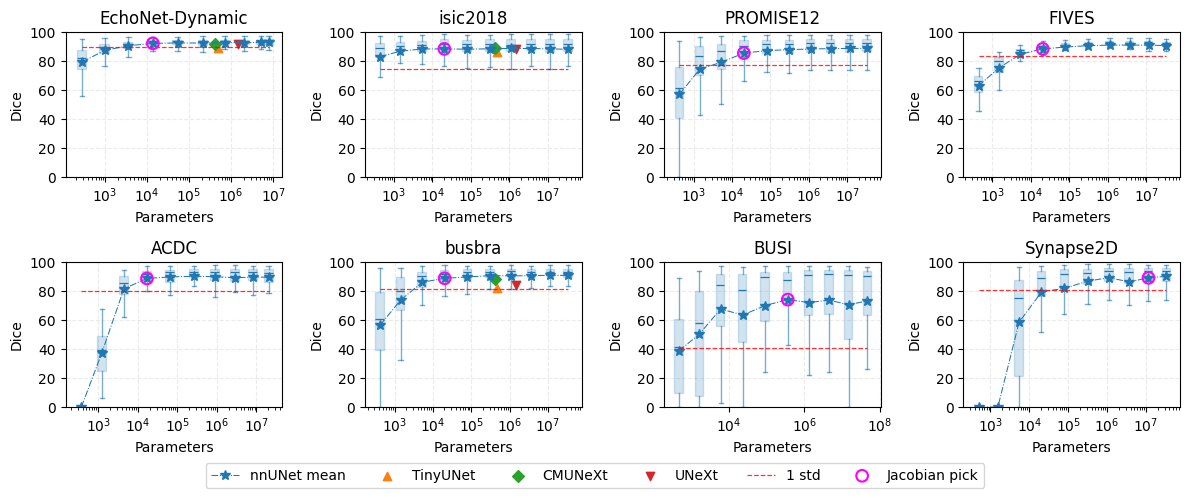

In [7]:
# Additional analysis level: violin distributions of per-case Dice by cfg (keeps existing line/fill analysis intact)

def get_dice_per_case(model_dir, split="val", fold=0):
    if split == "val":
        metrics_file = f"{model_dir}/fold_{fold}/validation/summary.json"
    else:
        raise ValueError(f"Not implemented for split {split}")

    with open(metrics_file, "r") as f:
        metrics = json.load(f)

    values = []
    for case in metrics.get("metric_per_case", []):
        case_metrics = case.get("metrics", {})
        class_key = next(iter(case_metrics), None)
        if class_key is None:
            continue
        d = case_metrics[class_key].get("Dice")
        if d is not None:
            values.append(float(d))

    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return arr


plot_violin = True
plot_distribution_as = "box"  # "violin" or "box"
plot_violin_means = True
plot_violin_baselines = True
plot_violin_2d_minus_1std_line = True
plot_violin_jacobian_pick = True

jacobian_pick_by_dataset = {}
fig = plt.figure(figsize=(12, 5))
for i, dataset_id in enumerate(dataset_ids):
    dataset_name = get_dataset_name(dataset_id)

    params_list = []
    dice_mean_list = []
    dice_std_list = []
    dice_cases_list = []
    jacobian_list = []

    for cfg in cfgs:
        model_dir = f"{results_dir}/{model}/{dataset_name}/{trainer}__{plans}__{cfg}"
        params = extract_params(model_dir)

        cases = np.array([], dtype=float)
        try:
            cases = get_dice_per_case(model_dir, split=split, fold=fold)
        except FileNotFoundError:
            pass

        if cases.size > 0:
            dice_mean = float(np.mean(cases) * 100)
            dice_std = float(np.std(cases) * 100)
        else:
            dice_mean = np.nan
            dice_std = np.nan

        jacobian = get_jacobian_metric(
            cfg,
            dataset_name,
            nas_metrics_dir=nas_metrics_dir,
            encoder_only=encoder_only,
            use_pretrained=use_pretrained,
            batches=batches,
        )

        params_list.append(params)
        dice_mean_list.append(dice_mean)
        dice_std_list.append(dice_std)
        dice_cases_list.append(cases * 100 if cases.size > 0 else np.array([], dtype=float))
        jacobian_list.append(jacobian)

    plt.subplot((len(dataset_ids) + 2) // 4, 4, i + 1)
    ax = plt.gca()

    colors = sns.color_palette(n_colors=len(baselines) + 1)
    markers = ['^', 'D', 'v', 'X', '^', '<', '>', 'p', 'h', 'H', '8', '1']

    params_arr = np.asarray(params_list, dtype=float)
    valid_params = np.isfinite(params_arr) & (params_arr > 0)
    mean_arr = np.asarray(dice_mean_list, dtype=float)
    std_arr = np.asarray(dice_std_list, dtype=float)

    # Violin distributions (one per cfg) at parameter positions
    violin_pos = []
    violin_data = []
    for j, pval in enumerate(params_arr):
        if np.isfinite(pval) and pval > 0 and dice_cases_list[j].size > 0:
            violin_pos.append(float(pval))
            violin_data.append(dice_cases_list[j])

    if plot_violin and len(violin_data) > 0:
        widths = [max(1.0, pos * 0.5) for pos in violin_pos]
        if plot_distribution_as == "box":
            bxp = ax.boxplot(
                violin_data,
                positions=violin_pos,
                widths=widths,
                patch_artist=True,
                showfliers=False,
            )
            for box in bxp['boxes']:
                box.set_facecolor(colors[0])
                box.set_edgecolor(colors[0])
                box.set_alpha(0.2)
            for med in bxp['medians']:
                med.set_color(colors[0])
                med.set_linewidth(0.9)
            for item in ('whiskers', 'caps'):
                for line in bxp[item]:
                    line.set_color(colors[0])
                    line.set_alpha(0.6)
        else:
            v = ax.violinplot(
                violin_data,
                positions=violin_pos,
                widths=widths,
                showmeans=False,
                showmedians=True,
                showextrema=False,
            )
            for b in v['bodies']:
                b.set_facecolor(colors[0])
                b.set_edgecolor(colors[0])
                b.set_alpha(0.2)
            if 'cmedians' in v:
                v['cmedians'].set_color(colors[0])
                v['cmedians'].set_linewidth(0.8)

    if plot_violin_means:
        valid_mean = valid_params & np.isfinite(mean_arr)
        if np.any(valid_mean):
            label = "nnUNet mean" if i == 0 else "_nolegend_"
            ax.plot(
                params_arr[valid_mean],
                mean_arr[valid_mean],
                marker='*',
                linestyle='dashdot',
                linewidth=0.75,
                markersize=7,
                color=colors[0],
                label=label,
            )

    if plot_violin_baselines and dataset_id in [300, 301, 302]:
        baseline_results = get_baseline_results(dataset_id, models=baselines, results_dir=results_dir)
        for b, baseline_model in enumerate(baselines):
            d = baseline_results[baseline_model]['dice']
            pval = baseline_results[baseline_model]['params']
            label = baseline_model if i == 0 else "_nolegend_"
            ax.scatter(pval, d, label=label, color=colors[b + 1], marker=markers[b])

    if plot_violin_2d_minus_1std_line and "2d" in cfgs:
        idx_2d = cfgs.index("2d")
        if idx_2d < len(mean_arr) and idx_2d < len(std_arr):
            d2d = mean_arr[idx_2d]
            s2d = std_arr[idx_2d]
            if np.isfinite(d2d) and np.isfinite(s2d) and np.any(valid_params):
                x_pos = params_arr[valid_params]
                y_line = d2d - s2d
                line_label = "1 std" if i == 0 else "_nolegend_"
                ax.hlines(
                    y_line,
                    x_pos.min(),
                    x_pos.max(),
                    colors='red',
                    linestyles='dashed',
                    linewidth=0.9,
                    alpha=0.8,
                    label=line_label,
                )

    jacobian_metrics = np.asarray([np.nan if pd.isna(n) else float(n) for n in jacobian_list], dtype=float)
    valid_jacobian = np.isfinite(jacobian_metrics)
    if np.any(valid_jacobian):
        jac_min = np.nanmin(jacobian_metrics)
        jac_max = np.nanmax(jacobian_metrics)
        if jac_max > jac_min:
            jacobian_metrics = (jacobian_metrics - jac_min) / (jac_max - jac_min)

    assert not (use_relative_change and use_derivative), "Cannot use both relative change and derivative"
    if use_relative_change:
        jacobian_metrics = [np.nan] + [abs(jacobian_metrics[j] - jacobian_metrics[j - 1]) for j in range(1, len(jacobian_metrics))]
        valid_vals = [x for x in jacobian_metrics if not np.isnan(x)]
        if len(valid_vals) > 0 and (max(valid_vals) - min(valid_vals)) > 0:
            jacobian_metrics = [np.nan if np.isnan(x) else (x - min(valid_vals)) / (max(valid_vals) - min(valid_vals)) for x in jacobian_metrics]
    elif use_derivative:
        jacobian_metrics = [np.nan] + [
            abs(jacobian_metrics[j] - jacobian_metrics[j - 1]) / abs(np.log10(params_list[j]) - np.log10(params_list[j - 1]))
            if params_list[j] > 0 and params_list[j - 1] > 0 and (np.log10(params_list[j]) - np.log10(params_list[j - 1])) != 0
            else np.nan
            for j in range(1, len(jacobian_metrics))
        ]

    if plot_violin_jacobian_pick:
        selected_cfg_idx, _ = select_precollapse_config_from_jacobian(
            params_list,
            jacobian_metrics,
            pre_collapse_rank=jacobian_precollapse_rank,
            min_seg=min_seg,
        )
        if selected_cfg_idx is not None:
            jacobian_pick_by_dataset[dataset_id] = cfgs[selected_cfg_idx]
            if np.isfinite(params_arr[selected_cfg_idx]) and params_arr[selected_cfg_idx] > 0 and np.isfinite(mean_arr[selected_cfg_idx]):
                pick_label = "Jacobian pick" if i == 0 else "_nolegend_"
                ax.scatter(
                    params_arr[selected_cfg_idx],
                    mean_arr[selected_cfg_idx],
                    marker='o',
                    s=70,
                    facecolors='none',
                    edgecolors='magenta',
                    linewidths=1.5,
                    zorder=7,
                    label=pick_label,
                )

    ax.set_xlabel('Parameters')
    ax.set_ylabel('Dice')
    ax.set_title(f'{dataset_name.split("_")[1]}')
    ax.set_xscale('log')
    ax.set_ylim(bottom=0, top=100)
    x_left, x_right = ax.get_xlim()
    if x_left > 0:
        ax.set_xlim(left=x_left / 2.5, right=x_right)
    
    ax.grid(True, alpha=0.25, linestyle='--')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=7)

save_path = f"{save_dir}/dice_violin_vs_params.png"
if plot_distribution_as == "box":
    save_path = save_path.replace("dice_violin_vs_params", "dice_box_vs_params")
if plot_violin_2d_minus_1std_line:
    save_path = save_path.replace('.png', '_with_2d_minus_1std.png')
if plot_violin_jacobian_pick:
    save_path = save_path.replace('.png', '_with_jacobian_pick.png')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"saved to {save_path}")
plt.show()


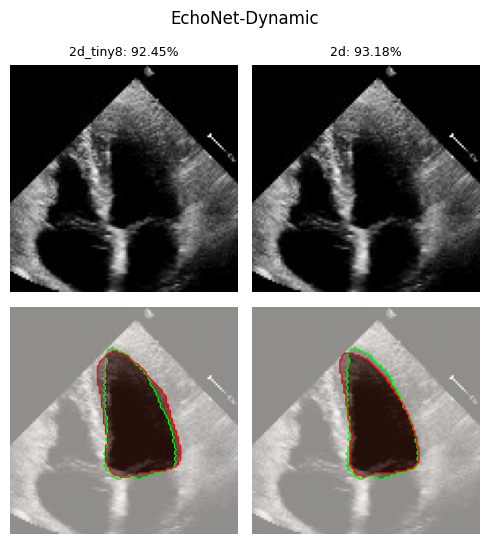

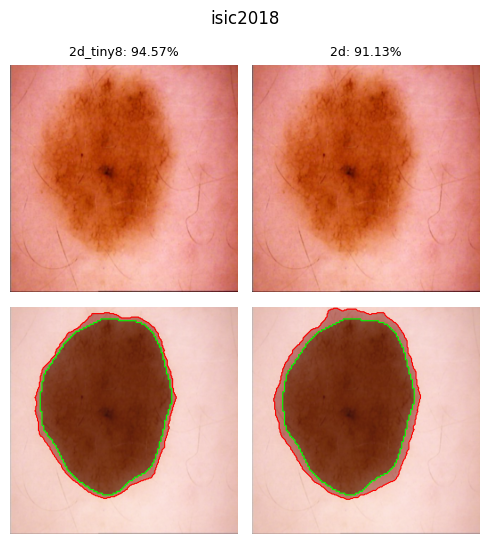

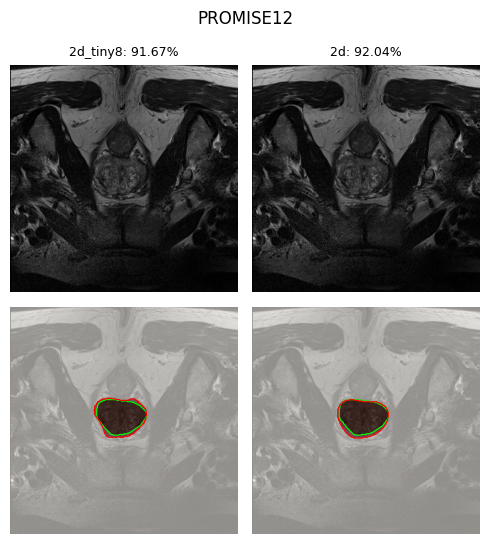

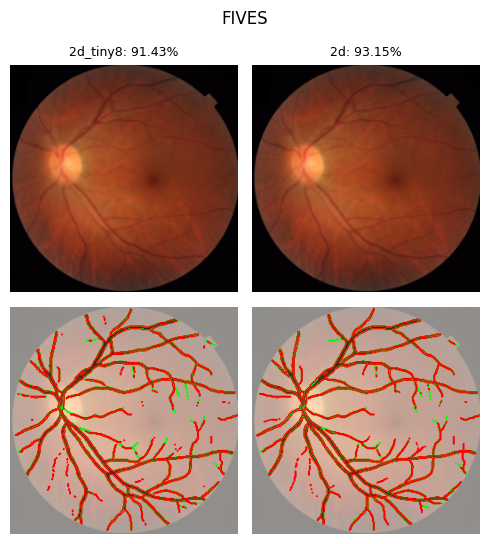

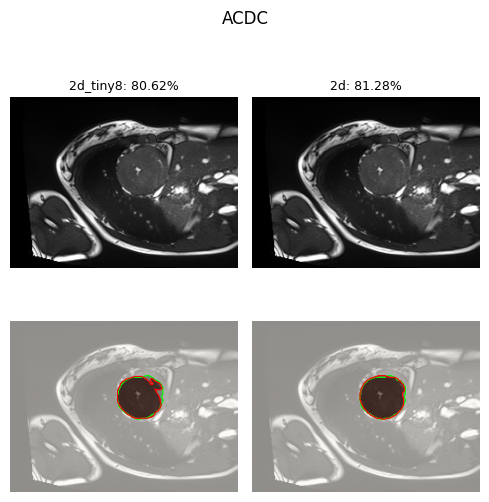

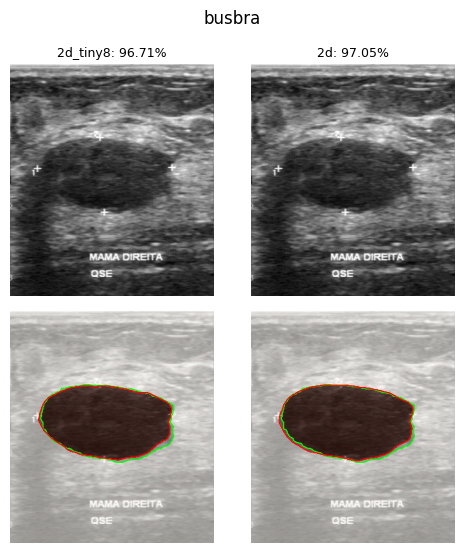

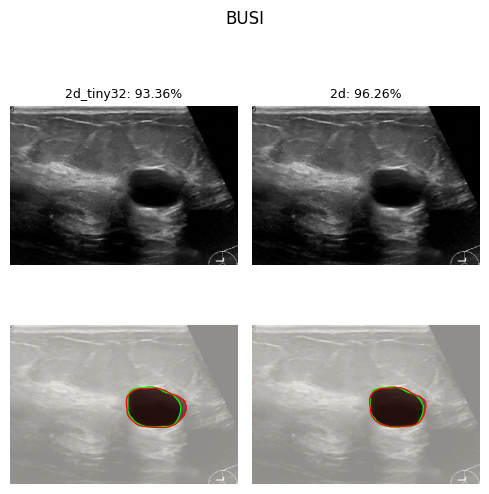

Dataset305_Synapse2D: skipped (filtered)


In [8]:
# Controls
single_case_cfg_ref = '2d'      # choose case from this cfg per dataset
single_case_mode = 'random'      # 'worst', 'best', 'random'
single_case_rank = 0             # used for worst/best
single_case_seed = 0
use_random_seed = False  # set False for fully random sampling each run
overlay_alpha = 0.35
skip_dataset_ids = set()
skip_dataset_name_keywords = {'synapse'}

for d_i, dataset_id in enumerate(dataset_ids):
    dataset_name = get_dataset_name(dataset_id)

    if dataset_id in skip_dataset_ids or any(k in dataset_name.lower() for k in skip_dataset_name_keywords):
        print(f"{dataset_name}: skipped (filtered)")
        continue

    # pick one case from reference cfg for this dataset
    ref_rows = _case_rows_for_cfg(dataset_id, single_case_cfg_ref)
    case_id = _pick_one_case_id(
        ref_rows,
        mode=single_case_mode,
        rank=single_case_rank,
        seed=single_case_seed + d_i,
        use_seed=use_random_seed,
    )

    if case_id is None:
        print(f"{dataset_name}: skipped (missing summary.json or no cases for cfg={single_case_cfg_ref})")
        continue

    jacobian_pick = globals().get('jacobian_pick_by_dataset', {}).get(dataset_id, None)
    last_cfg = cfgs[-1]

    if jacobian_pick is None:
        print(f"{dataset_name}: skipped (jacobian pick not available; run pick-computing cell first)")
        continue

    selected_cfgs = [jacobian_pick, last_cfg]
    n_cfg = len(selected_cfgs)
    fig, axes = plt.subplots(2, n_cfg, figsize=(max(2.0 * n_cfg, 5), 5.6), squeeze=False)

    # preload case maps only for selected cfgs
    rows_by_cfg = {}
    maps_by_cfg = {}
    for cfg in selected_cfgs:
        rows_cfg = _case_rows_for_cfg(dataset_id, cfg)
        rows_by_cfg[cfg] = rows_cfg
        maps_by_cfg[cfg] = {r['case_id']: r for r in rows_cfg}

    for col, cfg in enumerate(selected_cfgs):
        row = maps_by_cfg[cfg].get(case_id, None)

        # fallback if this case missing for a cfg
        if row is None and len(rows_by_cfg[cfg]) > 0:
            row = rows_by_cfg[cfg][0]

        if row is None:
            axes[0, col].axis('off')
            axes[1, col].axis('off')
            axes[0, col].set_title(f"{cfg}:NA", fontsize=9)
            continue

        pred = _read_image_array(row['pred_path'])
        gt = _read_image_array(row['gt_path'])

        img, _ = _resolve_raw_case_image(dataset_name, row['case_id'], nnunet_raw='data/nnUNet_raw')
        if img is None:
            img_disp = np.zeros_like(gt, dtype=np.float32)
        else:
            img_disp = _normalize_for_display(img, percentile_normalize=_is_ct_dataset_name(dataset_name))

        pred_mask = (pred > 0).astype(np.uint8)
        gt_mask = (gt > 0).astype(np.uint8)

        dice_text = 'NaN' if not np.isfinite(row['dice']) else f"{row['dice'] * 100:.2f}"

        # Row 0: image only
        axes[0, col].imshow(img_disp, cmap='gray' if img_disp.ndim == 2 else None)
        axes[0, col].set_title(f"{cfg}: {dice_text}%", fontsize=9)
        axes[0, col].axis('off')

        # Row 1: overlay
        axes[1, col].imshow(img_disp, cmap='gray' if img_disp.ndim == 2 else None)
        axes[1, col].imshow(gt_mask, cmap='Greens', alpha=overlay_alpha, vmin=0, vmax=1)
        axes[1, col].imshow(pred_mask, cmap='Reds', alpha=overlay_alpha, vmin=0, vmax=1)
        try:
            axes[1, col].contour(gt_mask, levels=[0.5], colors='lime', linewidths=0.8)
            axes[1, col].contour(pred_mask, levels=[0.5], colors='red', linewidths=0.8)
        except Exception:
            pass
        axes[1, col].axis('off')
    axes[0, 0].set_ylabel('Image', fontsize=10)
    axes[1, 0].set_ylabel('Overlay', fontsize=10)

    fig.suptitle(f"{dataset_name.split('_')[1]}") #\ncase={case_id}") #\n cols=[jacobian_pick, last_cfg]", y=1.02)
    plt.tight_layout()
    plt.show()
